# Task 1: Classifier for Mutations Only
## Overview
This script implements a classifier for Task 1, focusing on mutation data analysis. It includes:
- Data loading and preprocessing
- Feature engineering (mutation counts, types, flanking sequences, normalized rates)
- Visualizations comparing mutation patterns across train and test data
- Model training using RandomForest and XGBoost
- Evaluation metrics and performance analysis

In [19]:
# Install required libraries
!pip install pandas numpy scikit-learn matplotlib xgboost cudf-cu12 biopython imblearn --extra-index-url=https://pypi.nvidia.com

import os
import sys

# Set working directory and create output directory
os.chdir('/content/work')
sys.path.insert(0, '/content/work')
os.makedirs('out', exist_ok=True)
output_dir = 'out'

import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
import cudf
import torch
from extract_sequences import extract_sequences

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('task1_log.txt'),
        logging.StreamHandler()
    ]
)


# Check GPU availability
if torch.cuda.is_available():
    logging.info(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    logging.error("GPU not available. Please enable GPU runtime in Colab.")
    raise SystemExit("GPU not available.")

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


## Phase 1: Data Loading
Loads mutation data, feature data, and gene information using GPU-accelerated CSV reading.
Performs initial checks for missing values and gene validation.

In [3]:
logging.info("Loading data for Task 1...")
try:
    train_muts = cudf.read_csv('train_muts_data.csv').to_pandas()
    test_muts = cudf.read_csv('test_muts_data.csv').to_pandas()
    train_feats = cudf.read_csv('train_feats.csv').to_pandas()
    test_feats = cudf.read_csv('test_feats.csv').to_pandas()
    genes_100 = cudf.read_csv('100_genes.csv').to_pandas()
except FileNotFoundError as e:
    logging.error(f"File not found: {e}")
    raise SystemExit(f"Error: File not found: {e}")

# Convert 100_genes.csv to FASTA
logging.info("Writing 100_genes.fasta from genes_100 DataFrame...")
try:
    with open('100_genes.fasta', 'w') as fw:
        for _, row in genes_100.iterrows():
            fw.write(f">{row['gene']}\n{row['Sequence']}\n")
    logging.info("100_genes.fasta written successfully")
except Exception as e:
    logging.error(f"Error writing FASTA file: {e}")
    raise SystemExit(f"Error writing FASTA: {e}")

# Check for missing values
logging.info("Checking for missing values...")
for df, name in [(train_muts, 'train_muts'), (test_muts, 'test_muts'), (train_feats, 'train_feats'), (test_feats, 'test_feats')]:
    missing = df.isnull().sum().sum()
    logging.info(f"{name}: {missing} missing values")
    if missing > 0:
        logging.warning(f"{name} contains {missing} missing values")

# Verify required columns
required_cols = ['Gene_name', 'Start_Position', 'End_Position']
for df, name in [(train_muts, 'train_muts'), (test_muts, 'test_muts')]:
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        logging.error(f"{name} missing columns: {missing_cols}")
        raise ValueError(f"{name} is missing required columns: {missing_cols}")

# Verify genes
gene_set = set(genes_100['gene'])
invalid_train_genes = set(train_muts['Gene_name']) - gene_set
invalid_test_genes = set(test_muts['Gene_name']) - gene_set
if invalid_train_genes:
    logging.warning(f"{len(invalid_train_genes)} genes in train_muts not in 100_genes: {invalid_train_genes}")
if invalid_test_genes:
    logging.warning(f"{len(invalid_test_genes)} genes in test_muts not in 100_genes: {invalid_test_genes}")

# Display label distribution
logging.info("Label Distribution in Training Data:")
logging.info(train_feats['Label'].value_counts().to_string())

## Phase 2: Feature Engineering
Generates mutation features including:
- Total mutations
- Variant classifications
- Gene-specific mutations
- Mutation types (Transition, Transversion, etc.)
- Genomic context (flanking sequences, GC content, CpG sites)
- Mutation signatures
- Normalized mutation rates

In [4]:
logging.info("Creating mutation features for Task 1...")

# Extract flanking sequences
logging.info("Extracting flanking sequences...")
try:
    train_muts['flank_seq'] = extract_sequences('100_genes.fasta', train_muts, window_size=10)
    test_muts['flank_seq'] = extract_sequences('100_genes.fasta', test_muts, window_size=10)
except FileNotFoundError:
    logging.error("100_genes.fasta not found in /content/work/")
    raise SystemExit("Error: 100_genes.fasta not found")
except Exception as e:
    logging.error(f"Error extracting sequences: {e}")
    raise SystemExit(f"Error extracting sequences: {e}")

# Debug invalid flanking sequences
invalid_seqs_train = train_muts['flank_seq'].isna() | (train_muts['flank_seq'] == '')
invalid_seqs_test = test_muts['flank_seq'].isna() | (test_muts['flank_seq'] == '')
logging.info(f"Train mutations with invalid flanking sequences: {invalid_seqs_train.sum()}/{len(train_muts)}")
logging.info(f"Test mutations with invalid flanking sequences: {invalid_seqs_test.sum()}/{len(test_muts)}")
if invalid_seqs_train.sum() > len(train_muts) * 0.1 or invalid_seqs_test.sum() > len(test_muts) * 0.1:
    logging.warning("High number of invalid flanking sequences. Inspecting causes...")
    invalid_train = train_muts[invalid_seqs_train][['case_id', 'Gene_name', 'Start_Position', 'End_Position']]
    invalid_test = test_muts[invalid_seqs_test][['case_id', 'Gene_name', 'Start_Position', 'End_Position']]
    logging.info("Sample invalid train mutations:\n%s", invalid_train.head().to_string())
    logging.info("Sample invalid test mutations:\n%s", invalid_test.head().to_string())
    logging.info("Unique genes in invalid train mutations: %s", invalid_train['Gene_name'].unique().tolist())

# Extract genomic context features
logging.info("Extracting genomic context features...")
def extract_genomic_features(mutations_df):
    mutations_df['gc_content'] = 0.0
    mutations_df['is_cpg_site'] = False
    mutations_df['seq_complexity'] = 0.0
    valid_seqs = mutations_df['flank_seq'].notna() & (mutations_df['flank_seq'] != '')
    if valid_seqs.any():
        mutations_df.loc[valid_seqs, 'gc_content'] = mutations_df.loc[valid_seqs, 'flank_seq'].apply(
            lambda x: (x.count('G') + x.count('C')) / len(x) if x else 0)
        mutations_df.loc[valid_seqs, 'is_cpg_site'] = mutations_df.loc[valid_seqs].apply(
            lambda row: row['flank_seq'][9:11] == 'CG' if len(row['flank_seq']) >= 21 else False, axis=1)
        def sequence_entropy(seq):
            if not seq:
                return 0
            freq = pd.Series(list(seq)).value_counts(normalize=True)
            return -(freq * np.log2(freq)).sum()
        mutations_df.loc[valid_seqs, 'seq_complexity'] = mutations_df.loc[valid_seqs, 'flank_seq'].apply(sequence_entropy)
    genomic_features = pd.DataFrame()
    gc_stats = mutations_df.groupby('case_id')['gc_content'].agg(['mean', 'std']).fillna(0)
    genomic_features['Mean_GC_Content'] = gc_stats['mean']
    genomic_features['Std_GC_Content'] = gc_stats['std']
    cpg_props = mutations_df.groupby('case_id')['is_cpg_site'].mean()
    genomic_features['CpG_Site_Prop'] = cpg_props
    seq_stats = mutations_df.groupby('case_id')['seq_complexity'].agg(['mean', 'std']).fillna(0)
    genomic_features['Mean_Seq_Complexity'] = seq_stats['mean']
    genomic_features['Std_Seq_Complexity'] = seq_stats['std']
    return genomic_features

train_genomic_features = extract_genomic_features(train_muts)
test_genomic_features = extract_genomic_features(test_muts)

# Extract mutation signatures
logging.info("Analyzing mutation signatures...")
def extract_mutation_signatures(mutations_df):
    mutations_df['trinucleotide'] = 'NNN'
    valid_seqs = mutations_df['flank_seq'].notna() & (mutations_df['flank_seq'] != '') & (mutations_df['flank_seq'].str.len() >= 21)
    mutations_df.loc[valid_seqs, 'trinucleotide'] = mutations_df.loc[valid_seqs, 'flank_seq'].apply(
        lambda x: x[9:12] if len(x) >= 21 else 'NNN')
    signatures = pd.get_dummies(mutations_df['trinucleotide'])
    signatures = signatures.div(signatures.sum(axis=1), axis=0).fillna(0)
    signature_features = signatures.groupby(mutations_df['case_id']).mean()
    apobec_context = mutations_df['trinucleotide'].apply(
        lambda x: len(x) >= 2 and x[1] in ['C', 'G'] and x[0] in ['T', 'A'])
    mutations_df['is_apobec'] = apobec_context
    apobec_prop = mutations_df.groupby('case_id')['is_apobec'].mean()
    signature_features['APOBEC_Signature'] = apobec_prop
    return signature_features

train_signatures = extract_mutation_signatures(train_muts)
test_signatures = extract_mutation_signatures(test_muts)

# Total mutations per patient
train_total_muts = train_muts.groupby('case_id').size().reset_index(name='Total_Mutations')
test_total_muts = test_muts.groupby('case_id').size().reset_index(name='Total_Mutations')

# Mutations per variant classification
all_variant_types = pd.concat([train_muts['Variant_Classification'], test_muts['Variant_Classification']]).unique()
train_var_counts = train_muts.groupby(['case_id', 'Variant_Classification']).size().unstack(fill_value=0)
train_var_counts = train_var_counts.reindex(columns=all_variant_types, fill_value=0)
train_var_counts.columns = [f'Mutations_{col}' for col in train_var_counts.columns]
test_var_counts = test_muts.groupby(['case_id', 'Variant_Classification']).size().unstack(fill_value=0)
test_var_counts = test_var_counts.reindex(columns=all_variant_types, fill_value=0)
test_var_counts.columns = [f'Mutations_{col}' for col in test_var_counts.columns]

# Mutations per variant classification per gene
all_genes = pd.concat([train_muts['Gene_name'], test_muts['Gene_name']]).unique()
train_gene_var = train_muts.groupby(['case_id', 'Gene_name', 'Variant_Classification']).size().unstack(level=[1, 2], fill_value=0)
train_gene_var = train_gene_var.reindex(columns=pd.MultiIndex.from_product([all_genes, all_variant_types]), fill_value=0)
train_gene_var.columns = [f'Mutations_in_{gene}_{var}' for gene, var in train_gene_var.columns]
test_gene_var = test_muts.groupby(['case_id', 'Gene_name', 'Variant_Classification']).size().unstack(level=[1, 2], fill_value=0)
test_gene_var = test_gene_var.reindex(columns=pd.MultiIndex.from_product([all_genes, all_variant_types]), fill_value=0)
test_gene_var.columns = [f'Mutations_in_{gene}_{var}' for gene, var in test_gene_var.columns]

# Mutation type classification
def classify_mutation(row):
    ref, tumor = row['Reference_Allele'], row['Tumor_Seq_Allele1']
    if len(ref) == len(tumor) == 1:
        transitions = {('A', 'G'), ('G', 'A'), ('C', 'T'), ('T', 'C')}
        return 'Transition' if (ref, tumor) in transitions else 'Transversion'
    elif len(ref) > len(tumor):
        return 'Deletion'
    elif len(ref) < len(tumor):
        return 'Insertion'
    return 'Other'

logging.info("Classifying mutation types...")
train_muts['Mut_Type'] = train_muts.apply(classify_mutation, axis=1)
test_muts['Mut_Type'] = test_muts.apply(classify_mutation, axis=1)

# Check Mut_Type distribution
logging.info("Mutation type distribution in train_muts:")
mut_type_dist_train = train_muts['Mut_Type'].value_counts()
logging.info(mut_type_dist_train.to_string())
other_prop_train = mut_type_dist_train.get('Other', 0) / len(train_muts)
if other_prop_train > 0.1:
    logging.warning(f"High proportion of 'Other' mutations in train_muts: {other_prop_train:.2%}")

logging.info("Mutation type distribution in test_muts:")
mut_type_dist_test = test_muts['Mut_Type'].value_counts()
logging.info(mut_type_dist_test.to_string())
other_prop_test = mut_type_dist_test.get('Other', 0) / len(test_muts)
if other_prop_test > 0.1:
    logging.warning(f"High proportion of 'Other' mutations in test_muts: {other_prop_test:.2%}")

all_mut_types = pd.concat([train_muts['Mut_Type'], test_muts['Mut_Type']]).unique()
train_mut_types = train_muts.groupby(['case_id', 'Mut_Type']).size().unstack(fill_value=0)
train_mut_types = train_mut_types.reindex(columns=all_mut_types, fill_value=0)
train_mut_types.columns = [f'Mutations_{col}' for col in train_mut_types.columns]
test_mut_types = test_muts.groupby(['case_id', 'Mut_Type']).size().unstack(fill_value=0)
test_mut_types = test_mut_types.reindex(columns=all_mut_types, fill_value=0)
test_mut_types.columns = [f'Mutations_{col}' for col in test_mut_types.columns]

# Normalized mutation rate
genes_100['Length'] = genes_100['Sequence'].apply(len)

train_norm_muts = train_muts.groupby(['case_id', 'Gene_name']).size().reset_index(name='Count')
train_norm_muts = train_norm_muts.merge(genes_100[['gene', 'Length']], left_on='Gene_name', right_on='gene')
train_norm_muts['Norm_Mutations'] = train_norm_muts['Count'] / train_norm_muts['Length']
train_norm_muts = train_norm_muts.pivot(index='case_id', columns='Gene_name', values='Norm_Mutations').fillna(0)
train_norm_muts.columns = [f'Norm_Mutations_in_{col}' for col in train_norm_muts.columns]
train_norm_muts = train_norm_muts.reindex(columns=[f'Norm_Mutations_in_{g}' for g in all_genes], fill_value=0)

test_norm_muts = test_muts.groupby(['case_id', 'Gene_name']).size().reset_index(name='Count')
test_norm_muts = test_norm_muts.merge(genes_100[['gene', 'Length']], left_on='Gene_name', right_on='gene')
test_norm_muts['Norm_Mutations'] = test_norm_muts['Count'] / test_norm_muts['Length']
test_norm_muts = test_norm_muts.pivot(index='case_id', columns='Gene_name', values='Norm_Mutations').fillna(0)
test_norm_muts.columns = [f'Norm_Mutations_in_{col}' for col in test_norm_muts.columns]
test_norm_muts = test_norm_muts.reindex(columns=[f'Norm_Mutations_in_{g}' for g in all_genes], fill_value=0)

# Combine all features
logging.info("Combining features...")

train_features = train_total_muts.set_index('case_id').join([
    train_var_counts, train_gene_var, train_mut_types, train_norm_muts,
    train_genomic_features, train_signatures
]).reset_index()

test_features = test_total_muts.set_index('case_id').join([
    test_var_counts, test_gene_var, test_mut_types, test_norm_muts,
    test_genomic_features, test_signatures
]).reset_index()

# Align test_features columns with train_features
logging.info("Aligning feature columns...")
try:
    feature_columns = train_features.columns.difference(['case_id'])
    if not feature_columns.any():
        logging.error("No feature columns found after combining features")
        raise ValueError("No feature columns available")

    missing_cols = [col for col in feature_columns if col not in test_features.columns]
    if missing_cols:
        logging.info(f"Adding {len(missing_cols)} features to test_features with zeros: {missing_cols[:5]}...")
        for col in missing_cols:
            test_features[col] = 0

    extra_cols = [col for col in test_features.columns if col not in train_features.columns and col != 'case_id']
    if extra_cols:
        logging.warning(f"Dropping {len(extra_cols)} extra columns from test_features: {extra_cols[:5]}...")
        test_features = test_features.drop(columns=extra_cols)

    # Reorder test_features columns to match train_features order (except 'case_id')
    test_features = test_features.set_index('case_id').reindex(columns=feature_columns).reset_index()
except Exception as e:
    logging.error(f"Error during feature alignment: {str(e)}")
    raise ValueError(f"Feature alignment failed: {e}")

# Feature scaling
logging.info("Scaling features...")
scaler = StandardScaler()
try:
    # Verify feature columns are numeric
    non_numeric_cols = [col for col in feature_columns if not np.issubdtype(train_features[col].dtype, np.number)]
    if non_numeric_cols:
        logging.error(f"Non-numeric columns found: {non_numeric_cols[:5]}")
        raise ValueError(f"Non-numeric features detected: {non_numeric_cols[:5]}")

    # Handle NaN/inf values
    train_features[feature_columns] = train_features[feature_columns].replace([np.inf, -np.inf], np.nan)
    test_features[feature_columns] = test_features[feature_columns].replace([np.inf, -np.inf], np.nan)

    train_features[feature_columns] = train_features[feature_columns].fillna(train_features[feature_columns].mean())
    test_features[feature_columns] = test_features[feature_columns].fillna(train_features[feature_columns].mean())

    train_features[feature_columns] = scaler.fit_transform(train_features[feature_columns])
    test_features[feature_columns] = scaler.transform(test_features[feature_columns])
except Exception as e:
    logging.error(f"Error during feature scaling: {str(e)}")
    raise ValueError(f"Feature scaling failed: {e}")

logging.info(f"Feature engineering completed. Total features: {len(feature_columns)}")


Streaming output truncated to the last 5000 lines.


## 📊 Phase 3: Visualizing Mutation Data
Creates visualizations for mutation distributions using both train and test data where possible.
- Mutation distribution by cancer type and variant type (train only, due to missing labels in test).
- Top 20 genes in mutation by count (train + test).

In [8]:
logging.info("Creating visualizations for Task 1...")
# Mutation Distribution by Cancer Type and Variant (Train Only)
try:
    train_muts_with_label = train_muts.merge(train_feats[['case_id', 'Label']], on='case_id', how='left')
    if 'Label_y' in train_muts_with_label.columns:
        train_muts_with_label['Label'] = train_muts_with_label['Label_y']
        train_muts_with_label = train_muts_with_label.drop(columns=['Label_x', 'Label_y'])
    grouped_data = train_muts_with_label.groupby(['Label', 'Variant_Classification']).size().unstack(fill_value=0)
    grouped_data.index = grouped_data.index.map({1.0: 'HNSC', 2.0: 'LUSC'})
    plt.figure(figsize=(12, 6))
    grouped_data.plot(kind='bar', stacked=True)
    plt.xlabel('Cancer')
    plt.ylabel('Number')
    plt.title('Mutation Distribution by Cancer Type and Variant Type (Train Data)')
    plt.legend(title='Variant Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'mutation_distribution_by_cancer_and_variant.png'), dpi=300)
    logging.info("Saved mutation_distribution_by_cancer_and_variant.png")
    plt.close()
except Exception as e:
    logging.error(f"Failed to create cancer type visualization: {str(e)}")
    print(f"Error creating visualization: {e}")

# Mutation Count per Gene (Train + Test)
try:
    all_muts = pd.concat([train_muts, test_muts], ignore_index=True)
    gene_totals = all_muts.groupby('Gene_name').size().sort_values(ascending=False).head(20)
    plt.figure(figsize=(12, 6))
    bars = gene_totals.plot(kind='bar')
    plt.xlabel('Gene')
    plt.ylabel('Number of Mutations')
    plt.title('Top 20 Genes by Mutation Count (Train + Test Data)')
    for bar in bars.patches:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height())}',
                ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'mutation_distribution_by_gene.png'), dpi=300)
    logging.info("Saved mutation_distribution_by_gene.png")
    plt.close()
except Exception as e:
    logging.error(f"Failed to create gene mutation visualization: {e}")
    print(f"Error creating visualization: {e}")

<Figure size 1200x600 with 0 Axes>

## Phase 4: Model Training and Evaluation
Trains and evaluates classifiers using:
- Feature selection (VarianceThreshold, SelectKBest)
- RandomForest and XGBoost with GridSearchCV
- Validation performance on 20% stratified split
- Comparison with baseline metrics

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:10:07] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


<Figure size 800x600 with 0 Axes>

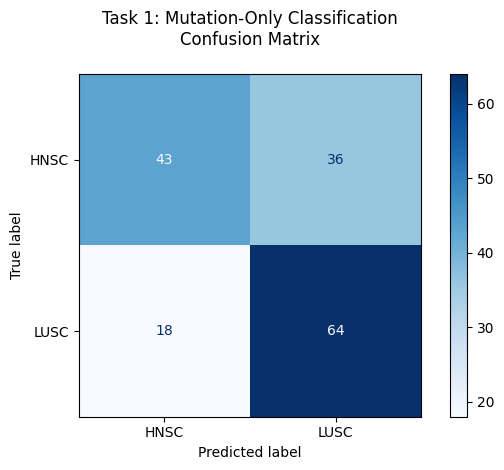


Task 1 completed. Outputs saved to out directory.


In [20]:
import logging
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline  # <-- استخدم pipeline من imblearn
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

logging.info("Training Task 1 classifier...")

try:
    train_data = train_features.merge(train_feats[['case_id', 'Label']], on='case_id')
    X_train = train_data.drop(columns=['case_id', 'Label']).fillna(0)
    y_train = train_data['Label'].astype(int) - 1  # Assuming labels start at 1
    X_test = test_features.drop(columns=['case_id']).fillna(0)
    # Align test columns with train columns (fill missing with 0)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
except Exception as e:
    logging.error(f"Error preparing training data: {e}")
    raise Exception(f"Data preparation failed: {e}")

logging.info("Performing feature selection...")
try:
    feature_names = X_train.columns.tolist()

    variance_threshold = VarianceThreshold(threshold=0.01)
    X_train_var = variance_threshold.fit_transform(X_train)
    X_test_var = variance_threshold.transform(X_test)

    selector = SelectKBest(score_func=f_classif, k=100)
    X_train_selected = selector.fit_transform(X_train_var, y_train)
    X_test_selected = selector.transform(X_test_var)

    variance_support = variance_threshold.get_support()
    selector_support = selector.get_support()

    variance_pass_indices = [i for i, v in enumerate(variance_support) if v]
    selected_feature_indices = [variance_pass_indices[i] for i, v in enumerate(selector_support) if v]
    feature_names = [feature_names[i] for i in selected_feature_indices]

except Exception as e:
    logging.error(f"Error during feature selection: {e}")
    raise Exception(f"Feature selection failed: {e}")

logging.info("Splitting data into train/validation sets...")
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_selected, y_train, test_size=0.2, stratify=y_train, random_state=42)

classifiers = {
    'RandomForest': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(
            scale_pos_weight=len(y_train[y_train==0]) / max(len(y_train[y_train==1]), 1),
            device='cuda',
            tree_method='hist',
            random_state=42))
    ])
}

best_classifier = None
best_score = 0
best_threshold = 0.5
metrics_comparison = []

logging.info("Training and evaluating classifiers...")
for name, classifier in classifiers.items():
    try:
        param_grid = {
            'RandomForest': {
                'clf__n_estimators': [100, 200, 300],
                'clf__max_depth': [3, 5, 7],
                'clf__min_samples_split': [2, 5]
            },
            'XGBoost': {
                'clf__max_depth': [3, 5, 7],
                'clf__learning_rate': [0.01, 0.1, 0.3],
                'clf__n_estimators': [100, 200, 300]
            }
        }[name]
        grid_search = GridSearchCV(classifier, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
        grid_search.fit(X_train_split, y_train_split)

        y_val_pred = grid_search.predict(X_val)
        if hasattr(grid_search, "predict_proba"):
            y_val_proba = grid_search.predict_proba(X_val)[:, 1]
        else:
            y_val_proba = grid_search.decision_function(X_val)
            y_val_proba = (y_val_proba - y_val_proba.min()) / (y_val_proba.max() - y_val_proba.min() + 1e-10)

        error = (y_val_pred != y_val).mean()
        f1 = f1_score(y_val, y_val_pred, average='weighted')
        precision = precision_score(y_val, y_val_pred, average='weighted')
        recall = recall_score(y_val, y_val_pred, average='weighted')

        metrics_comparison.append({
            'Model': name,
            'F1-Score': f1,
            'Precision': precision,
            'Recall': recall,
            'Error Rate': error
        })

        logging.info(f"{name} Results:")
        logging.info(f"Validation Error: {error:.4f}, F1-Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

        precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
        valid_idx = np.isfinite(f1_scores)
        if valid_idx.any():
            optimal_idx = np.argmax(f1_scores[valid_idx])
            best_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
            logging.info(f"Optimal threshold for {name}: {best_threshold:.3f}")

        if f1 > best_score:
            best_score = f1
            best_classifier = grid_search
            best_y_val_pred = y_val_pred  # حفظ أفضل تنبؤات للتحقق لاحقًا

    except Exception as e:
        logging.error(f"Error training {name}: {e}")
        continue

try:
    metrics_df = pd.DataFrame(metrics_comparison)
    logging.info("\nModel Performance Comparison:")
    logging.info("Expected baseline: F1-Score: 0.658, Precision: 0.676, Recall: 0.664")
    logging.info("\nActual performance:")
    logging.info(metrics_df.to_string(index=False))
except Exception as e:
    logging.error(f"Error displaying metrics: {e}")

if best_classifier:
    logging.info("Saving predictions...")
    try:
        best_classifier.fit(X_train_selected, y_train)
        y_test_proba = best_classifier.predict_proba(X_test_selected)[:, 1]
        y_test_pred = (y_test_proba >= best_threshold).astype(int) + 1

        pd.DataFrame({
            'id': test_features['case_id'],
            'label_predict': y_test_pred
        }).to_csv(os.path.join(output_dir, 'task1_predictions.csv'), index=False)

        logging.info("Saved task1_predictions.csv")

    except Exception as e:
        logging.error(f"Failed to save predictions: {e}")
        raise Exception(f"Prediction saving failed: Error during prediction: {e}")

    try:
        importances = best_classifier.best_estimator_.named_steps['clf'].feature_importances_
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        logging.info("\nTop 10 Features:")
        logging.info(feature_importance_df.head(10).to_string())

        feature_importance_df.to_csv(os.path.join(output_dir, 'feature_importance_task1.csv'), index=False)
        logging.info(f"Saved feature_importance_task1.csv")
    except Exception as e:
        logging.error(f"Error saving feature importance: {e}")

    try:
        plt.figure(figsize=(8, 6))
        disp = ConfusionMatrixDisplay.from_predictions(
            y_val, best_y_val_pred, labels=[0, 1], display_labels=['HNSC', 'LUSC'], cmap='Blues')
        plt.title('Task 1: Mutation-Only Classification\nConfusion Matrix\n')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'confusion_matrix_task1.png'), dpi=300)
        plt.show()
        logging.info("Saved confusion_matrix_task1.png")
        plt.close()
    except Exception as e:
        logging.error(f"Failed to save confusion matrix: {e}")

logging.info("Task 1 completed. Outputs saved to out directory.")
print("\nTask 1 completed. Outputs saved to out directory.")